1. AI가 OPIC 질문 생성
2. 사용자 답변
3. AI가 피드백

START -> Question Generator -> User Answer -> Evaluator -> END

In [ ]:
# %pip install speechrecognition pyaudio

# 1. API 설정

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from openai import OpenAI

client = OpenAI()

# 2. 데이터 베이스 구축

In [4]:
import sqlite3

conn = sqlite3.connect("question.db")
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS questions (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    question TEXT NOT NULL,
    audio_path TEXT NOT NULL
)
""")

conn.commit()

In [5]:
import pandas as pd

df = pd.read_csv('예상질문모음집.csv')
df.head()

,id,category,question,audio
0,1,self_intro,Please introduce yourself.,NaN
1,2,home,Please describe your home in detail.,NaN
2,3,home,What do you usually do at home during your fre...,NaN
3,4,home,How is your current home different from the ho...,NaN
4,5,movie,What is your favorite movie? Please describe it.,NaN


In [ ]:
# 오디오 생성
# 양이 많아지면, 배치 처리

# import re

# def make_filename(text):
#     text = re.sub(r'[\\/:*?"<>|]', '', text)
#     return text + ".mp3"


# for i in range(len(df)):
#     question = df.loc[i, "question"]

#     filename = make_filename(question)

#     with client.audio.speech.with_streaming_response.create(
#         model="gpt-4o-mini-tts",
#         voice="coral",
#         input=question,
#         instructions="Speak in a cheerful and positive tone.",
#     ) as response:

#         response.stream_to_file(filename)

In [3]:
import sqlite3

conn = sqlite3.connect("question.db")
cursor = conn.cursor()

# cursor.execute("SELECT * FROM questions")
cursor.execute("""
    SELECT *
    FROM questions
""")

rows = cursor.fetchall()

for row in rows:
    print(row)

(1, 'Please introduce yourself.', 'C:\\Users\\User\\Desktop\\multi-agent\\03_multi_agent__intermediate\\practice\\question\\1.mp3')
(2, 'Please describe your home in detail.', 'C:\\Users\\User\\Desktop\\multi-agent\\03_multi_agent__intermediate\\practice\\question\\2.mp3')
(3, 'What do you usually do at home during your free time?', 'C:\\Users\\User\\Desktop\\multi-agent\\03_multi_agent__intermediate\\practice\\question\\3.mp3')
(4, 'How is your current home different from the home you lived in when you were younger?', 'C:\\Users\\User\\Desktop\\multi-agent\\03_multi_agent__intermediate\\practice\\question\\4.mp3')
(5, 'What is your favorite movie? Please describe it.', 'C:\\Users\\User\\Desktop\\multi-agent\\03_multi_agent__intermediate\\practice\\question\\5.mp3')
(6, 'What do you usually do when you go to watch a movie?', 'C:\\Users\\User\\Desktop\\multi-agent\\03_multi_agent__intermediate\\practice\\question\\6.mp3')
(7, 'Tell me about the first movie that made a strong impression 

질문 -> 녹음                     -> 피드백 -> END
        -> 다시 녹음 하고 싶다면
        -> 피드백을 받고 싶다면?

# 3. State 

In [24]:
from typing import TypedDict

class OpicState(TypedDict):
    question: str
    answer: str
    transcript: str
    feedback: str
    action: str

# 4. 노드
## 4-(1). 질문 노드

In [ ]:
# test

import pygame

pygame.mixer.init()

pygame.mixer.music.load(
    r"C:\Users\User\Desktop\multi-agent\03_multi_agent__intermediate\practice\question\1.mp3"
)

pygame.mixer.music.play()

In [25]:
import pygame

def ask_question(state):
    question = "Please introduce yourself."
    print(f"📌 질문: {question}")
    
    pygame.mixer.init()

    pygame.mixer.music.load(
        r"C:\Users\User\Desktop\multi-agent\03_multi_agent__intermediate\practice\question\1.mp3"
    )

    pygame.mixer.music.play()

    return {
        "question": question
    }

## 4-(2). 녹음 노드

In [19]:
%pip install sounddevice scipy

  Using cached sounddevice-0.5.5-py3-none-win_amd64.whl.metadata (1.4 kB)
Using cached sounddevice-0.5.5-py3-none-win_amd64.whl (365 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
import sounddevice as sd
from scipy.io.wavfile import write
from pathlib import Path
from datetime import datetime

Path("answer").mkdir(exist_ok=True)

def record_answer(state):

    duration = 30 # 시간(s)
    sample_rate = 16000

    print("🎤 녹음 시작...")

    recording = sd.rec(
        int(duration * sample_rate),
        samplerate=sample_rate,
        channels=1,
        dtype="int16"
    )

    sd.wait()

    answer = (
        f"answer/"
        f"answer_{datetime.now().strftime('%Y%m%d_%H%M%S')}.wav"
    )

    write(answer, sample_rate, recording)

    print(f"✅ 저장 완료: {answer}")

    return {
        "answer": answer
    }

## 4-(3). 녹음 -> 텍스트화

In [42]:
from openai import OpenAI

client = OpenAI()

def speech_to_text(state):

    with open(state["answer"], "rb") as audio_file:

        transcription = client.audio.transcriptions.create(
            model="gpt-4o-transcribe",
            file=audio_file
        )

    transcript = transcription.text

    print("\n📝 변환 결과")
    print(transcript)

    
    return {
        "transcript": None
    }

## 4-(4). 피드백 노드

In [43]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4.1")

def give_feedback(state):

    prompt = f"""
You are a friendly and encouraging OPIc speaking coach.

Question:
{state['question']}

Answer:
{state['transcript']}

Your task is to provide personalized feedback in Korean.

Requirements:
- Speak like a warm and supportive English tutor.
- Do NOT use sections such as "1. Overall Evaluation", "2. Fluency", etc.
- Do NOT list scores or grades.
- Combine grammar, vocabulary, fluency, and content feedback into one natural paragraph.
- Focus on the single most important improvement point.
- Mention strengths first, then suggest improvements.
- Keep the feedback concise (2~4 sentences).
- Use polite and encouraging Korean.
- Avoid harsh criticism.
- End with a motivating sentence.

Examples of tone:
- "자연스럽게 자기소개를 시작한 점이 좋습니다."
- "조금 더 구체적인 경험을 덧붙이면 더욱 풍부한 답변이 될 것 같아요."
- "취미나 관심사를 한두 문장 정도 추가해보는 연습을 추천드립니다."
- "충분히 좋은 시작이에요. 조금만 더 내용을 확장하면 훨씬 자연스러운 답변이 될 수 있습니다."

Output only the feedback in Korean.
"""

    feedback = llm.invoke(prompt).content

    print(feedback)

    return {
        "feedback": feedback
    }

## 4-(5). 사용자 선택 노드

In [44]:
def choose_action(state):

    print("\n1. 다시 녹음")
    print("2. 종료")

    choice = input("> ")

    if choice == "1":
        action = "retry"
    else:
        action = "end"

    return {
        "action": action
    }

## 4-(6). Router

In [45]:
def route(state):

    if state["action"] == "retry":
        return "record"

    return "end"

# 5. Graph

In [46]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(OpicState)

graph.add_node("ask", ask_question)
graph.add_node("record", record_answer)
graph.add_node("speech_to_text", speech_to_text)
graph.add_node("feedback", give_feedback)
graph.add_node("choose", choose_action)

graph.add_edge(START, "ask")
graph.add_edge("ask", "record")
graph.add_edge("record", "speech_to_text")
graph.add_edge("speech_to_text", "feedback")
graph.add_edge("feedback", "choose")

graph.add_conditional_edges(
    "choose",
    route,
    {
        "record": "record",
        "end": END
    }
)

app = graph.compile()

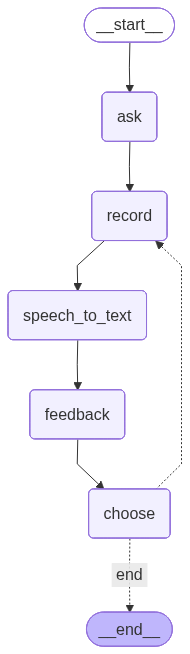

In [47]:
from IPython.display import Image, display

display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)

In [48]:
result = app.invoke({})
print(result)

📌 질문: Please introduce yourself.
🎤 녹음 시작...
✅ 저장 완료: answer/answer_20260605_172426.wav

📝 변환 결과

아직 답변이 없지만, 스스로 소개할 준비를 하고 계시다는 점에서 좋은 출발이에요. 간단하게 자신의 이름과 관심사 정도부터 시작해보면 부담 없이 답변을 완성할 수 있을 거예요. 너무 걱정하지 마시고, 자신감을 가지고 연습해보세요!

1. 다시 녹음
2. 종료
🎤 녹음 시작...
✅ 저장 완료: answer/answer_20260605_172510.wav

📝 변환 결과
Thank you.
차분하게 답변을 시작하는 태도가 인상적입니다. 다음 번에는 본인의 간단한 성격이나 취미를 한두 문장 추가해보면 답변이 더 풍부해질 것 같아요. 앞으로도 계속 연습하시면 더 자신감 있게 말할 수 있을 거예요!

1. 다시 녹음
2. 종료
{'question': 'Please introduce yourself.', 'answer': 'answer/answer_20260605_172510.wav', 'transcript': None, 'feedback': '차분하게 답변을 시작하는 태도가 인상적입니다. 다음 번에는 본인의 간단한 성격이나 취미를 한두 문장 추가해보면 답변이 더 풍부해질 것 같아요. 앞으로도 계속 연습하시면 더 자신감 있게 말할 수 있을 거예요!', 'action': 'end'}


In [39]:
from pathlib import Path
from openai import OpenAI
import pygame

client = OpenAI()


def question(question):
    question = "Please introduce yourself."
    pygame.mixer.init()
    pygame.mixer.music.load(str("03_multi_agent__intermediate\\practice\\question\\1.mp3"))
    pygame.mixer.music.play()
    return {"question": question}

In [40]:
# 3. DB 돌면서 

In [41]:
# import sqlite3
# import pygame
# from pathlib import Path
# from time import sleep

# # pygame 초기화
# pygame.mixer.init()

# # DB 연결
# conn = sqlite3.connect("question.db")
# cursor = conn.cursor()

# # 질문 조회
# cursor.execute("""
# SELECT question, audio_path
# FROM questions
# """)

# rows = cursor.fetchall()

# for idx, (question, audio_path) in enumerate(rows, start=1):

#     print(f"\n[{idx}] {question}")

#     audio_file = Path(audio_path)

#     if audio_file.exists():
#         pygame.mixer.music.load(str(audio_file))
#         pygame.mixer.music.play()

#         # 재생이 끝날 때까지 대기
#         while pygame.mixer.music.get_busy():
#             sleep(0.1)

#     else:
#         print(f"파일 없음: {audio_file}")

# conn.close()


[1] Please introduce yourself.

[2] Please describe your home in detail.

[3] What do you usually do at home during your free time?

[4] How is your current home different from the home you lived in when you were younger?

[5] What is your favorite movie? Please describe it.

[6] What do you usually do when you go to watch a movie?

[7] Tell me about the first movie that made a strong impression on you.


In [42]:
import speech_recognition as sr


def speech_to_text(state):
    recognizer = sr.Recognizer()
    with sr.Microphone() as source:
        recognizer.adjust_for_ambient_noise(source)

        audio = recognizer.listen(
            source,
            timeout=None,
            phrase_time_limit=60
    )
    try:
        text = recognizer.recognize_google(audio)

        print("\n===== Your Answer =====")
        print(text)

        return {
            "answer": text
        }

    except Exception as e:
        print(e)

        return {
            "answer": ""
    }


In [ ]:
def evaluate_answer(state):

    prompt = f"""
Evaluate this OPIc self-introduction.

Answer:
{state['answer']}

Please evaluate:

1. Grammar
2. Vocabulary
3. Fluency
4. Naturalness

Give a score from 1-5 for each category.

Then provide one improved version.
"""

    result = evaluator_llm.invoke(prompt)

    return {
        "feedback": result.content
    }

In [ ]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(OpicState)

builder.add_node("generate_question", generate_question)
builder.add_node("speech_to_text", speech_to_text)
builder.add_node("evaluate_answer", evaluate_answer)

builder.add_edge(START, "generate_question")
builder.add_edge("generate_question", "speech_to_text")
builder.add_edge("speech_to_text", "evaluate_answer")
builder.add_edge("evaluate_answer", END)

graph = builder.compile()

In [ ]:
from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except:
    print("ERROR")

In [ ]:
result = graph.invoke({})

In [ ]:
print("\n===== Feedback =====")
print(result["feedback"])